In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing
import matplotlib.pyplot as plt

*we can either use direct formulas for derivative calculation in L2 regularization as it forms closed loop solution were as L1 regularization uses manual calculation of derivative as it is non differentiable at "0" and it does not forms closed loop solution* 

**Using L2 Regularization**

In [2]:
class L2:
    def __init__(self, lambda_=2, lr=0.5, n_iters = 1000,tol = 1e-10):
        self.weights = None
        self.bias = None
        self.lr = lr
        self.tol = tol
        self.n_iters = n_iters
        self.loss_history =[]
        self.lambda_ = lambda_

    def fit(self,X,y):
        self.loss_history =[]
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for i in range(self.n_iters):
            y_pred = X.dot(self.weights) + self.bias

            loss = (1/(2*n_samples)) * (np.sum((y_pred-y)**2)) + (self.lambda_/(2*n_samples)) * np.sum(self.weights**2)
            self.loss_history.append(loss)

            #breaking loop when change in loss is very minor
            if abs(self.loss_history[i-1] - loss)<self.tol and i>1:
                print(f"tolerance reached at iteration {i+1}")
                break

            #change in weights and bias 
            dw = (1/n_samples)*(X.T.dot(y_pred-y)) + (self.lambda_/n_samples) * np.sum(self.weights)
            db = (1/n_samples)*(np.sum(y_pred-y))

            #updation
            self.weights -= self.lr*dw
            self.bias -= self.lr*db

    def predict(self,X):
        return X.dot(self.weights) + self.bias 

In [3]:
data = fetch_california_housing()
X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [4]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [5]:
M2 = L2(lambda_=3,lr=0.5,n_iters=1000)

In [6]:
M2.fit(X_train,y_train)
y_pred = M2.predict(X_test)

tolerance reached at iteration 392


In [7]:
print(M2.loss_history[:10])

[np.float64(2.8148711615515656), np.float64(0.9422806523828163), np.float64(0.47565782204479196), np.float64(0.35492778081544785), np.float64(0.3210737629844836), np.float64(0.3094215215667081), np.float64(0.3036924418182293), np.float64(0.2997287874649301), np.float64(0.29643614376440625), np.float64(0.2935066611917036)]


In [8]:
print(M2.loss_history[-10:])

[np.float64(0.25919439892827656), np.float64(0.2591943988091949), np.float64(0.25919439869300637), np.float64(0.25919439857963944), np.float64(0.25919439846902403), np.float64(0.25919439836109226), np.float64(0.2591943982557777), np.float64(0.2591943981530158), np.float64(0.2591943980527436), np.float64(0.25919439795489974)]


In [9]:
loss_history = M2.loss_history

[]

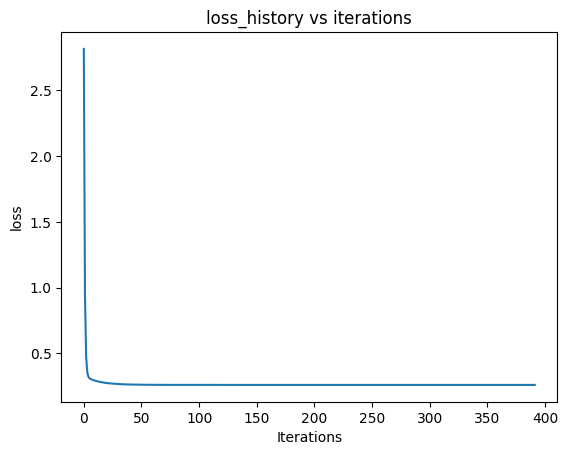

In [10]:
plt.plot(loss_history)
plt.title("loss_history vs iterations")
plt.xlabel("Iterations")
plt.ylabel("loss")
plt.plot()

**L1 Regularization**

In [11]:
class L1:
    def __init__(self, lambda_=2, lr=0.5, n_iters = 1000,tol = 1e-10):
        self.weights = None
        self.bias = None
        self.lr = lr
        self.tol = tol
        self.n_iters = n_iters
        self.loss_history =[]
        self.lambda_ = lambda_

    def fit(self,X,y):
        self.loss_history =[]
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for i in range(self.n_iters):
            y_pred = X.dot(self.weights) + self.bias

            loss = (1/(2*n_samples)) * (np.sum((y_pred-y)**2)) + (self.lambda_/(2*n_samples)) * np.sum(np.abs(self.weights))
            self.loss_history.append(loss)

            #breaking loop when change in loss is very minor
            if abs(self.loss_history[i-1] - loss)<self.tol and i>1:
                print(f"tolerance reached at iteration {i+1}")
                break

            #change in weights and bias 
            dw = (1/n_samples)*(X.T.dot(y_pred-y)) + (self.lambda_/(2*n_samples)) * np.sum(np.sign(self.weights))
            db = (1/n_samples)*(np.sum(y_pred-y))

            #updation
            self.weights -= self.lr*dw
            self.bias -= self.lr*db

    def predict(self,X):
        return X.dot(self.weights) + self.bias 

In [12]:
M1 = L1(lambda_=3, lr=0.5,n_iters=1000)
M1.fit(X_train,y_train)
y_pred = M1.predict(X_test)

tolerance reached at iteration 430


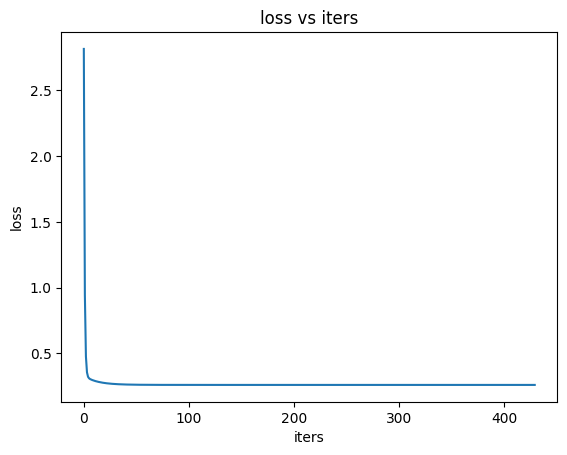

In [13]:
loss_history = M1.loss_history
plt.plot(loss_history)
plt.xlabel("iters")
plt.title("loss vs iters")
plt.ylabel("loss")
plt.show()

In [14]:
#loss of L1 regularization
M1.loss_history[-1]

np.float64(0.2592777916701418)

In [15]:
#loss of L2 regulariaztion 
M2.loss_history[-1]

np.float64(0.25919439795489974)

we can intrepret form losses of different models that L2 regularization achieved better results with less iterations  